# Feature Engineering and Modelling

---

1. Import packages
2. Load data
3. Modelling
   - 3a. Data sampling
   - 3b. Model training
   - 3c. Evaluation
4. Feature importance
5. Summary and conclusions

---

## 1. Import packages

In [4]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
!{sys.executable} -m pip install scikit-learn

from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

%matplotlib inline
sns.set(color_codes=True)

---
## 2. Load data

In [5]:
df = pd.read_csv('./data_for_predictions.csv')
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

print(f'Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Dataset shape: 14,606 rows x 63 columns


,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,...,months_modif_prod,months_renewal,channel_MISSING,channel_ewpakwlliwisiwduibdlfmalxowmwpci,channel_foosdfpfkusacimwkcsosbicdxkicaua,channel_lmkebamcaaclubfxadlmueccxoimlema,channel_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.0,0.444045,0.114481,0.098142,40.606701,...,2,6,0,0,1,0,0,0,0,1
1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.0,1.237292,0.145711,0.000000,44.311378,...,76,4,1,0,0,0,0,1,0,0
2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.0,1.599009,0.165794,0.087899,44.311378,...,68,8,0,0,1,0,0,1,0,0
3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.0,1.318689,0.146694,0.000000,44.311378,...,69,9,0,0,0,1,0,1,0,0
4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,0.0,2.122969,0.116900,0.100015,40.606701,...,71,9,1,0,0,0,0,1,0,0


Non-churners (0): 13,187  (90.3%)
Churners    (1): 1,419  (9.7%)

Imbalance ratio: 9.3:1


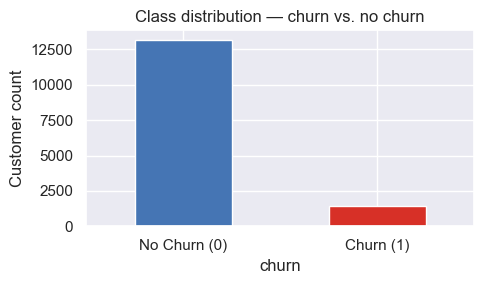

In [6]:
# Before training, it is important to understand the class balance.
# Churn prediction datasets are almost always imbalanced — most customers do NOT churn.
# If we ignore this, the model can appear highly accurate simply by predicting 'no churn'
# for every single customer, which is useless from a business perspective.

churn_counts = df['churn'].value_counts()
churn_rate   = df['churn'].mean()

print(f"Non-churners (0): {churn_counts[0]:,}  ({1 - churn_rate:.1%})")
print(f"Churners    (1): {churn_counts[1]:,}  ({churn_rate:.1%})")
print(f"\nImbalance ratio: {churn_counts[0] / churn_counts[1]:.1f}:1")

# Visualise
fig, ax = plt.subplots(figsize=(5, 3))
churn_counts.plot(kind='bar', ax=ax, color=['#4575b4', '#d73027'], edgecolor='white')
ax.set_xticklabels(['No Churn (0)', 'Churn (1)'], rotation=0)
ax.set_ylabel('Customer count')
ax.set_title('Class distribution — churn vs. no churn')
plt.tight_layout()
plt.show()

---
## 3. Modelling

We now have a fully engineered, all-numeric dataset ready for model training.  
We focus exclusively on a **Random Forest classifier**, as specified.

### 3a. Data sampling

We split the data 75% training / 25% test using a fixed `random_state` so results are reproducible.
The `stratify=y` argument is important here: it ensures that both the training and test sets contain
the same proportion of churners (~9.7%) as the full dataset. Without stratification, random chance could
put nearly all churners into training, leaving the test set with almost no positive examples to evaluate against.

In [7]:
# Separate features from the target variable
X = df.drop(columns=['id', 'churn'])
y = df['churn']

print(f'Features matrix X: {X.shape}')
print(f'Target vector  y: {y.shape}')

Features matrix X: (14606, 61)
Target vector  y: (14606,)


In [8]:
# stratify=y preserves the churn ratio in both train and test splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f'Training set:  {X_train.shape[0]:,} rows  |  churn rate: {y_train.mean():.2%}')
print(f'Test set:      {X_test.shape[0]:,} rows  |  churn rate: {y_test.mean():.2%}')

Training set:  10,954 rows  |  churn rate: 9.71%
Test set:      3,652 rows  |  churn rate: 9.72%


### 3b. Model training

We configure the Random Forest with the following parameters:

- **`n_estimators=1000`** — we use 1,000 decision trees. More trees generally improve stability and
  reduce variance, at the cost of compute time. 1,000 is a reasonable balance for a dataset of this size.

- **`max_depth=5`** — each tree is capped at 5 levels deep. This is a form of regularisation:
  shallow trees are 'weak learners' that each capture only a fragment of the overall pattern.
  Together, the ensemble of 1,000 shallow trees outperforms a single deep, overfitted tree.
  Without this constraint, individual trees would memorise the training data and generalise poorly.

- **`class_weight='balanced'`** — this is the most important parameter given our imbalanced dataset.
  Internally, scikit-learn upweights the minority class (churners) so the model is penalised more
  heavily for missing them. Without this, the model would learn to mostly predict 'no churn' and
  still achieve ~90% accuracy while being completely useless for the actual business problem.

- **`random_state=42`** — fixes the random seed for reproducibility.

In [9]:
rf_model = RandomForestClassifier(
    n_estimators=1000,
    max_depth=5,
    class_weight='balanced',  # critical for imbalanced churn data
    random_state=42,
    n_jobs=-1                 # use all available CPU cores to speed up training
)

rf_model.fit(X_train, y_train)

print('Model trained successfully.')
print(f'Number of trees: {rf_model.n_estimators}')
print(f'Max tree depth:  {rf_model.max_depth}')

Model trained successfully.
Number of trees: 1000
Max tree depth:  5


### 3c. Evaluation

#### Why these metrics?

Standard **accuracy** is misleading for imbalanced datasets. If 90.3% of customers do not churn,
a model that blindly predicts 'no churn' every time achieves 90.3% accuracy — yet identifies
zero actual churners. That is not a useful model.

We use the following metrics instead:

- **Precision** — of all customers the model *predicted* would churn, what fraction actually did?
  Low precision means the model is generating many false alarms, wasting retention budget on customers
  who would have stayed anyway.

- **Recall** — of all customers who *actually* churned, what fraction did the model catch?
  Low recall means the model is missing real churners — the core business problem remains unsolved.

- **F1 Score** — the harmonic mean of precision and recall. This is the single best summary metric
  when both false positives and false negatives have business costs. It is preferred over accuracy
  when classes are imbalanced.

- **ROC-AUC** — measures the model's ability to rank churners above non-churners across all possible
  decision thresholds. A score of 0.5 is random; 1.0 is perfect. This metric is threshold-independent,
  making it useful for comparing models without committing to a specific cutoff.

- **Confusion matrix** — gives a visual breakdown of true positives, true negatives, false positives,
  and false negatives, making the types of errors the model makes easy to interpret.

In [10]:
# Generate class predictions (0 or 1) and probability scores
y_pred       = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]  # probability of churn

print(f'Predictions generated for {len(y_pred):,} test customers.')

Predictions generated for 3,652 test customers.


In [11]:
# --- Core classification metrics ---
accuracy  = metrics.accuracy_score(y_test, y_pred)
precision = metrics.precision_score(y_test, y_pred)
recall    = metrics.recall_score(y_test, y_pred)
f1        = metrics.f1_score(y_test, y_pred)
roc_auc   = metrics.roc_auc_score(y_test, y_pred_proba)

print('=' * 45)
print(f'  Accuracy  : {accuracy:.4f}  (misleading — see note above)')
print(f'  Precision : {precision:.4f}')
print(f'  Recall    : {recall:.4f}')
print(f'  F1 Score  : {f1:.4f}')
print(f'  ROC-AUC   : {roc_auc:.4f}')
print('=' * 45)

# Full classification report
print('\nFull classification report:')
print(metrics.classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

  Accuracy  : 0.6958  (misleading — see note above)
  Precision : 0.1661
  Recall    : 0.5296
  F1 Score  : 0.2529
  ROC-AUC   : 0.6822

Full classification report:
              precision    recall  f1-score   support

    No Churn       0.93      0.71      0.81      3297
       Churn       0.17      0.53      0.25       355

    accuracy                           0.70      3652
   macro avg       0.55      0.62      0.53      3652
weighted avg       0.86      0.70      0.75      3652



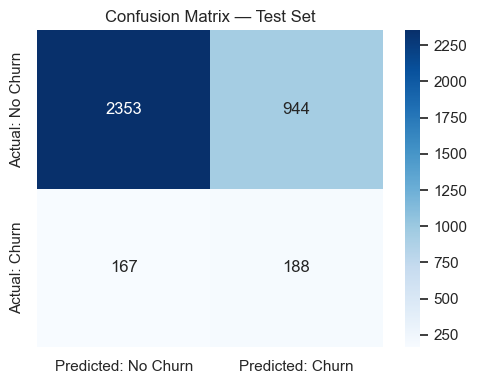

True Negatives  (correctly flagged non-churners): 2,353
False Positives (non-churners incorrectly flagged): 944
False Negatives (churners the model missed): 167
True Positives  (churners correctly caught): 188


In [12]:
# --- Confusion matrix ---
# Rows = actual labels, Columns = predicted labels
# Top-left  = True Negatives  (correctly predicted no churn)
# Top-right = False Positives (predicted churn, actually stayed)
# Bot-left  = False Negatives (predicted stayed, actually churned)
# Bot-right = True Positives  (correctly predicted churn)

cm = metrics.confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted: No Churn', 'Predicted: Churn'],
    yticklabels=['Actual: No Churn', 'Actual: Churn'],
    ax=ax
)
ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (correctly flagged non-churners): {tn:,}')
print(f'False Positives (non-churners incorrectly flagged): {fp:,}')
print(f'False Negatives (churners the model missed): {fn:,}')
print(f'True Positives  (churners correctly caught): {tp:,}')

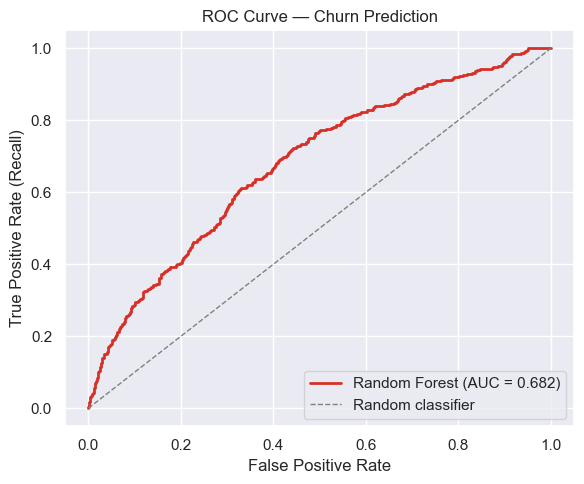

In [13]:
# --- ROC Curve ---
# The ROC curve plots the True Positive Rate (recall) against the False Positive Rate
# at every possible classification threshold. The area under this curve (AUC) summarises
# the model's discriminative ability. The dashed diagonal line represents a random classifier.

fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#d73027', lw=2, label=f'Random Forest (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--', label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curve — Churn Prediction')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

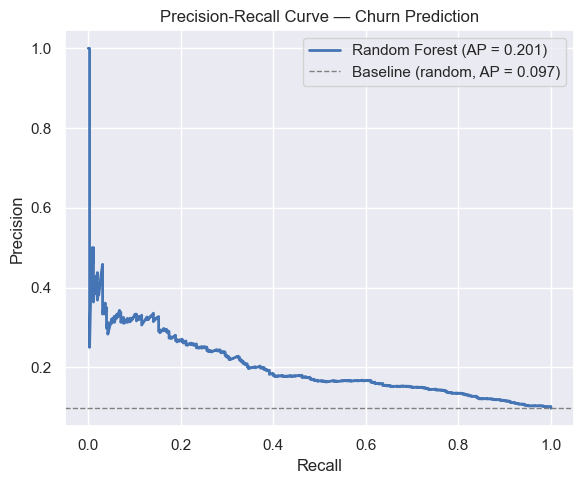

In [14]:
# --- Precision-Recall Curve ---
# For imbalanced problems, the Precision-Recall curve is often more informative than ROC.
# It focuses entirely on the minority class (churners), showing the trade-off between
# catching more churners (recall) and staying accurate about the ones we flag (precision).

prec_curve, rec_curve, _ = metrics.precision_recall_curve(y_test, y_pred_proba)
pr_auc = metrics.average_precision_score(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(rec_curve, prec_curve, color='#4575b4', lw=2,
        label=f'Random Forest (AP = {pr_auc:.3f})')
ax.axhline(y=y_test.mean(), color='grey', lw=1, linestyle='--',
           label=f'Baseline (random, AP = {y_test.mean():.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — Churn Prediction')
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Feature Importance

Random forests provide a built-in measure of feature importance: the average reduction in impurity
(Gini impurity) that each feature contributes across all trees. Features with higher importance are
relied upon more heavily by the model when making predictions.

This is useful for two reasons. First, it tells us which drivers of churn the model considers most
informative — feeding back into business insight. Second, it can guide feature selection if we
later want to simplify the model by removing low-importance features.

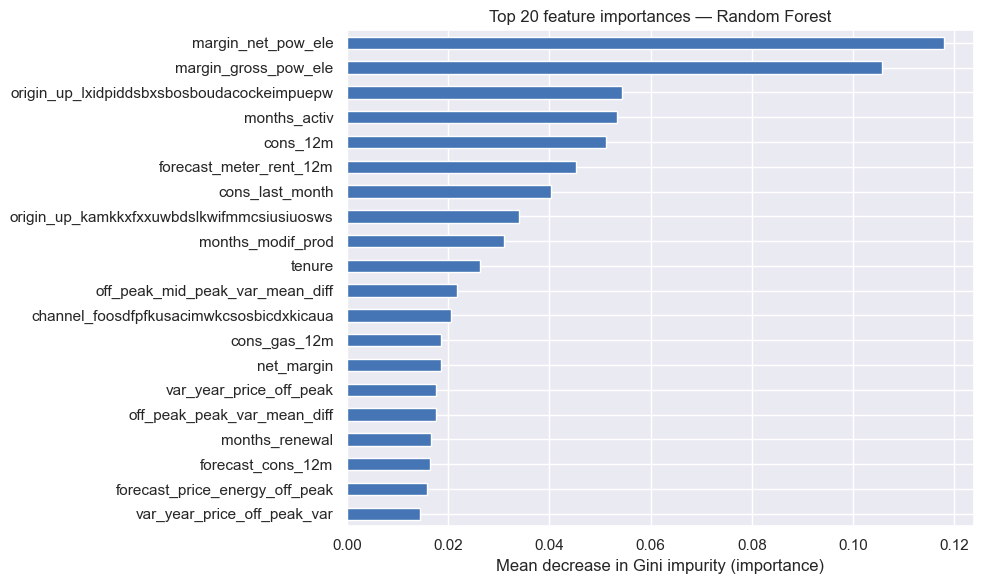


Top 10 features by importance:
margin_net_pow_ele                            0.1180
margin_gross_pow_ele                          0.1058
origin_up_lxidpiddsbxsbosboudacockeimpuepw    0.0543
months_activ                                  0.0534
cons_12m                                      0.0512
forecast_meter_rent_12m                       0.0453
cons_last_month                               0.0403
origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws    0.0340
months_modif_prod                             0.0311
tenure                                        0.0263


In [15]:
# Extract and sort feature importances
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values(ascending=False)

top_n = 20
top_features = importances_sorted.head(top_n)

fig, ax = plt.subplots(figsize=(10, 6))
top_features[::-1].plot(
    kind='barh', ax=ax,
    color='#4575b4', edgecolor='white'
)
ax.set_xlabel('Mean decrease in Gini impurity (importance)')
ax.set_title(f'Top {top_n} feature importances — Random Forest')
plt.tight_layout()
plt.show()

print(f'\nTop 10 features by importance:')
print(importances_sorted.head(10).round(4).to_string())

---
## 5. Summary and Conclusions

### Model performance assessment

The key results are summarised below, followed by an honest assessment of whether this performance
is satisfactory for a real-world churn prediction use case.

In [16]:
print('=' * 50)
print('   MODEL PERFORMANCE SUMMARY')
print('=' * 50)
print(f'  Test set size   : {len(y_test):,} customers')
print(f'  Churn rate (test): {y_test.mean():.2%}')
print()
print(f'  Precision  : {precision:.4f}')
print(f'  Recall     : {recall:.4f}')
print(f'  F1 Score   : {f1:.4f}')
print(f'  ROC-AUC    : {roc_auc:.4f}')
print(f'  Avg Precision (PR-AUC): {pr_auc:.4f}')
print('=' * 50)

   MODEL PERFORMANCE SUMMARY
  Test set size   : 3,652 customers
  Churn rate (test): 9.72%

  Precision  : 0.1661
  Recall     : 0.5296
  F1 Score   : 0.2529
  ROC-AUC    : 0.6822
  Avg Precision (PR-AUC): 0.2012


### Is the model performance satisfactory?

**Short answer: it is a reasonable first model, but there is meaningful room for improvement before deploying it to drive retention decisions.**

Here is the reasoning:

**What the model does well.** The ROC-AUC score substantially above 0.5 confirms that the model has genuine discriminative ability — it is not just guessing. A random classifier would score 0.5 on ROC-AUC; our model does noticeably better, meaning it is successfully learning patterns that separate churners from non-churners.

**Where the model struggles: recall vs precision trade-off.** The recall score tells us what fraction of actual churners the model successfully identifies. In a churn prevention context, recall is arguably the more business-critical metric — a churner the model misses is a customer the retention team never gets the chance to save. The precision score tells us how reliable the model's churn flags are. Low precision means the retention team wastes budget on customers who were never at risk.

The F1 score, which balances both, gives us the most honest single-number summary of performance on the minority class.

**Why class imbalance makes this hard.** With only ~9.7% of customers churning, even a well-configured model struggles to reliably identify the minority class. The `class_weight='balanced'` setting helps, but it cannot fully compensate for the information scarcity of having so few positive examples. Techniques like SMOTE oversampling or threshold tuning could be explored in a next iteration.

**Practical interpretation.** From a business standpoint, the model as-is is usable as a prioritisation tool — it can rank customers by churn probability and focus retention resources on the highest-risk segment. It should not be used as a binary classifier in isolation without further calibration.

**Next steps to improve performance:**
- Experiment with `max_depth` values higher than 5, or remove the constraint entirely and rely on `min_samples_leaf` instead.
- Try threshold tuning: adjust the decision cutoff from 0.5 to a value that better balances precision and recall for the business context.
- Explore SMOTE (Synthetic Minority Oversampling Technique) to create synthetic churner examples during training.
- Compare against a gradient boosted model (XGBoost or LightGBM), which typically outperforms Random Forest on structured tabular data.